In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import zipfile
object_zip=zipfile.ZipFile('/content/drive/MyDrive/Data Science/Machine Learning/chrun_modelling.zip')
object_zip.extractall()
object_zip.close()

In [3]:
path="/content/Churn_Modelling.csv"
df=pd.read_csv(path)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


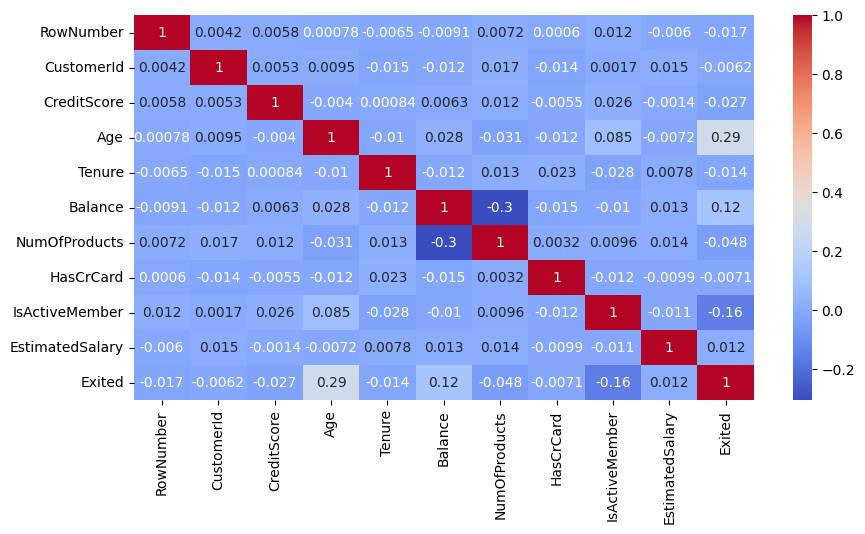

In [7]:
plt.figure(figsize=(10,5))
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [8]:
features=corr['Exited'].sort_values(ascending=False)[1:]

In [9]:
features.index

Index(['Age', 'Balance', 'EstimatedSalary', 'CustomerId', 'HasCrCard',
       'Tenure', 'RowNumber', 'CreditScore', 'NumOfProducts',
       'IsActiveMember'],
      dtype='object')

In [10]:
features.values

array([ 0.28532304,  0.11853277,  0.01209686, -0.00624799, -0.00713777,
       -0.01400061, -0.01657137, -0.02709354, -0.04781986, -0.15612828])

In [11]:
import warnings
warnings.filterwarnings('ignore')

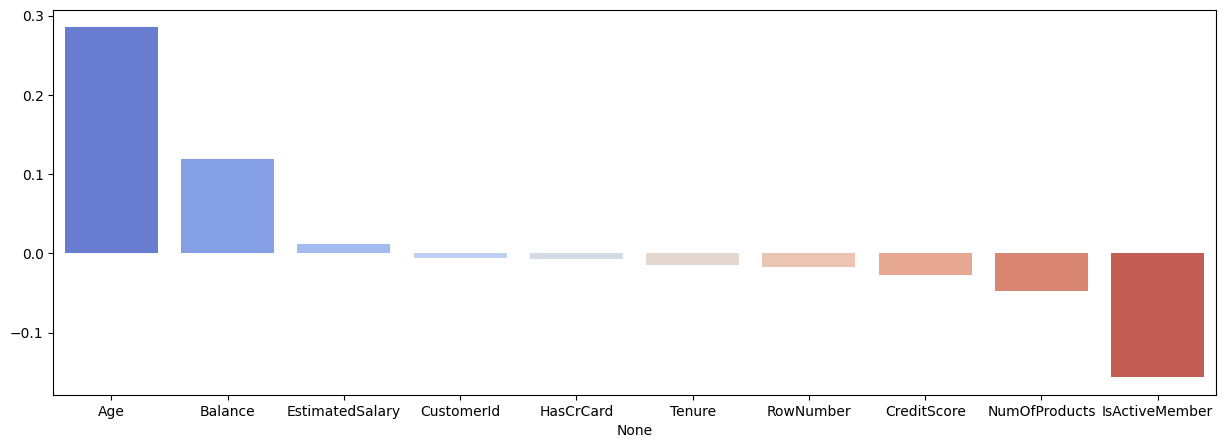

In [12]:
plt.figure(figsize=(15,5))
sns.barplot(x=features.index,y=features.values,palette='coolwarm')
plt.show()

Exited
0    7963
1    2037
Name: count, dtype: int64


<Axes: xlabel='Exited', ylabel='count'>

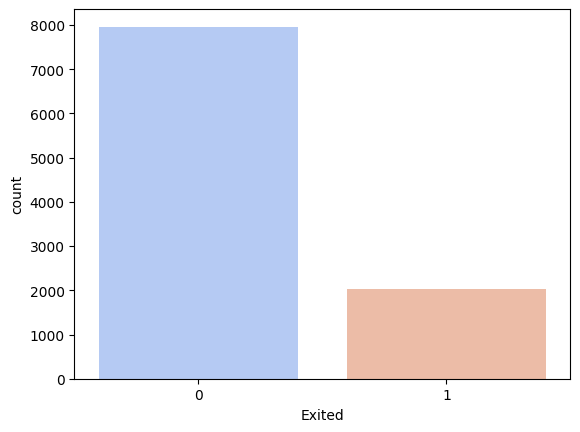

In [13]:
print(df['Exited'].value_counts())
sns.countplot(x='Exited',data=df,palette='coolwarm')

Gender
Male      5457
Female    4543
Name: count, dtype: int64


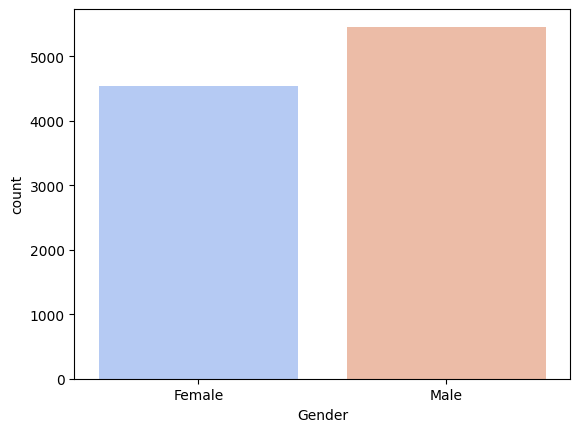

In [14]:
print(df['Gender'].value_counts())
sns.countplot(x='Gender',data=df,palette='coolwarm')
plt.show()

Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64


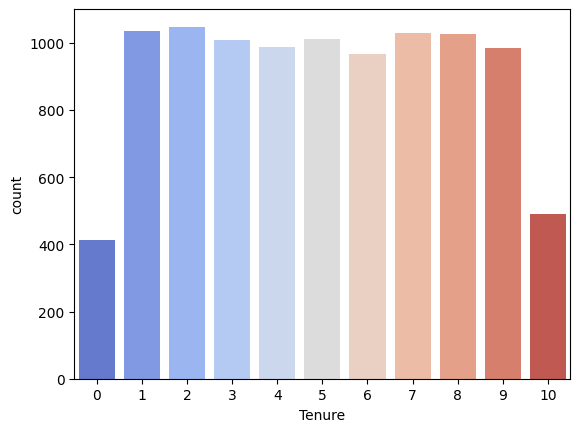

In [15]:
print(df['Tenure'].value_counts())
sns.countplot(x='Tenure',data=df,palette='coolwarm')
plt.show()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


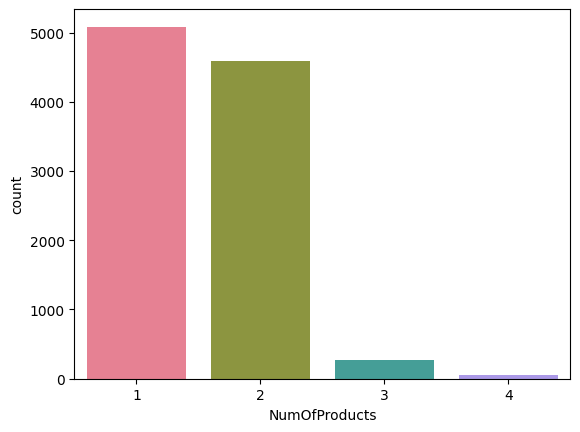

In [16]:
print(df['NumOfProducts'].value_counts())
sns.countplot(x='NumOfProducts',data=df,palette='husl')
plt.show()

HasCrCard
1    7055
0    2945
Name: count, dtype: int64


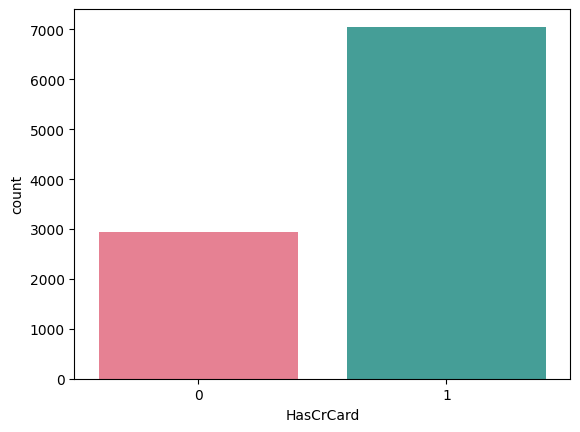

In [17]:
print(df['HasCrCard'].value_counts())
sns.countplot(x='HasCrCard',data=df,palette='husl')
plt.show()

**Feature Relations**

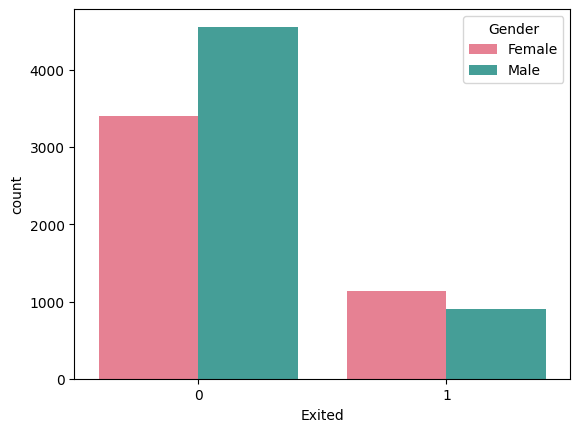

In [18]:
sns.countplot(x='Exited',
              data=df,
              hue='Gender',
              palette='husl')
plt.show()

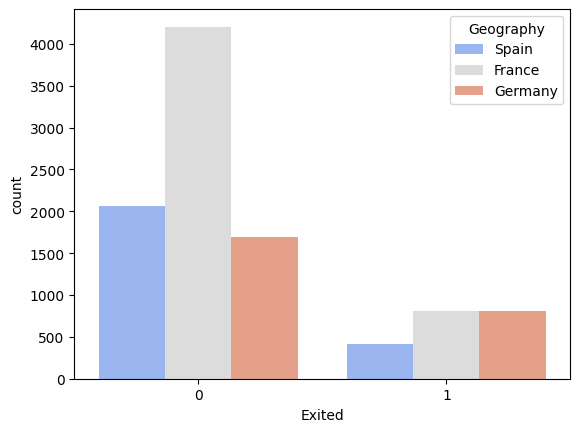

In [19]:
sns.countplot(x='Exited',
              data=df,
              hue='Geography',
              palette='coolwarm')
plt.show()

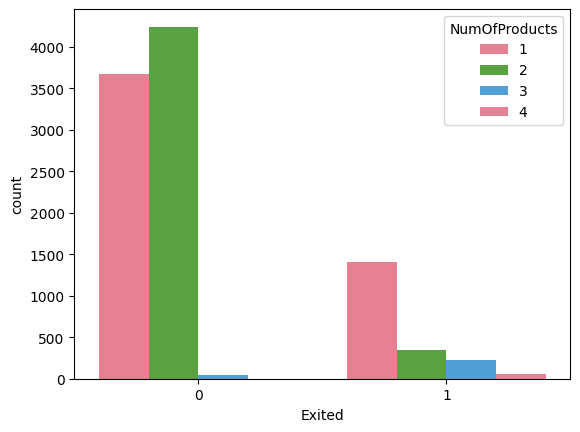

In [20]:
sns.countplot(x='Exited',
              data=df,
              hue='NumOfProducts',
              palette='husl')
plt.show()

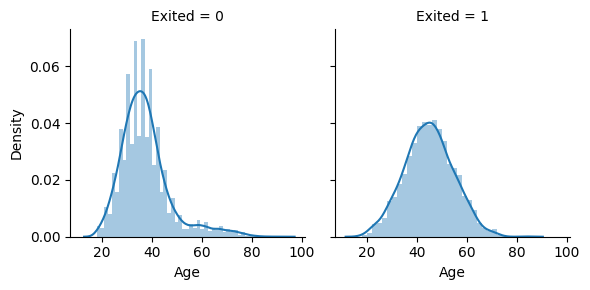

In [21]:
sns.FacetGrid(df,col='Exited')\
      .map(sns.distplot,"Age")
plt.show()

**Data Preprocessing**

In [22]:
df.drop(columns=['RowNumber',"CustomerId","Surname"],inplace=True)

In [23]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [24]:
df['Geography']=df['Geography'].astype('category').cat.codes

In [25]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,Female,42,2,0.00,1,1,1,101348.88,1
1,608,2,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,0,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,0,Female,39,1,0.00,2,0,0,93826.63,0
4,850,2,Female,43,2,125510.82,1,1,1,79084.10,0


In [26]:
# 0= france
# 1
# 2 = spain


In [27]:
df['Gender']=np.where(df['Gender']=='Male',1,0)

In [28]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [29]:
# 0 = female
# 1 = male

In [30]:
X=df.drop('Exited',axis=1).values
y=df['Exited'].values

In [31]:
X.shape

(10000, 10)

In [32]:
y.shape

(10000,)

In [33]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,
                                               random_state=123)

In [34]:
from xgboost import XGBClassifier
model=XGBClassifier()
model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [35]:
from sklearn.metrics import confusion_matrix,\
            classification_report,f1_score

In [36]:
def evaluate_model(model):
  print("Training accuracy:",model.score(X_train,y_train))
  print("Testing accuracy:",model.score(X_test,y_test))

  y_pred=model.predict(X_test)

  print(confusion_matrix(y_test,y_pred))
  print(classification_report(y_test,y_pred))
  print("F1 score:",f1_score(y_test,y_pred))

In [37]:
evaluate_model(model)


Training accuracy: 0.95975
Testing accuracy: 0.8585
[[1503   83]
 [ 200  214]]
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1586
           1       0.72      0.52      0.60       414

    accuracy                           0.86      2000
   macro avg       0.80      0.73      0.76      2000
weighted avg       0.85      0.86      0.85      2000

F1 score: 0.6019690576652602


**Hyperparameter Tuning**

In [38]:
from sklearn.model_selection import GridSearchCV

In [39]:
xgb_params={
    'n_estimators' : [100,200],
    'max_depth':[4,5]
}

In [40]:
grid=GridSearchCV(XGBClassifier(),
                  param_grid=xgb_params,
                  scoring='accuracy',cv=10)
grid.fit(X_train,y_train)

GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'max_depth': [4, 5], 'n_estimators': [100, 200]},
             scoring='accuracy')

In [41]:
print("Best score:",grid.best_score_)

Best score: 0.8608750000000001


In [42]:
print("Best score:",grid.best_params_)

Best score: {'max_depth': 4, 'n_estimators': 100}


In [43]:
model_1=XGBClassifier(max_depth=4)
model_1.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [44]:
evaluate_model(model_1)

Training accuracy: 0.90425
Testing accuracy: 0.866
[[1515   71]
 [ 197  217]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1586
           1       0.75      0.52      0.62       414

    accuracy                           0.87      2000
   macro avg       0.82      0.74      0.77      2000
weighted avg       0.86      0.87      0.86      2000

F1 score: 0.6182336182336182
